<a href="https://colab.research.google.com/github/XTMay/ML_DL/blob/main/NLP/ChineseTextClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/Users/xiaotingzhou/miniconda3/lib/python3.11/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/jieba.cache


中文电影评论情感分析系统演示

1. 创建示例数据集...
数据集大小: 20 条评论

数据样例:
                   review  sentiment label
0  这部电影太精彩了，剧情跌宕起伏，演员表演出色          1    正面
1     非常好看的电影，推荐大家观看，五星好评          1    正面
2    导演拍得很用心，每个细节都很棒，值得收藏          1    正面
3   演员演技在线，剧情引人入胜，是今年最佳电影          1    正面
4      画面精美，音乐动听，整体制作水准很高          1    正面

2. 数据预处理...


Loading model cost 0.283 seconds.
Prefix dict has been built successfully.



预处理前后对比:
原文: 这部电影太精彩了，剧情跌宕起伏，演员表演出色
处理后: 这部 电影 太精彩 剧情 跌宕起伏 演员 表演 出色

原文: 非常好看的电影，推荐大家观看，五星好评
处理后: 非常 好看 电影 推荐 大家 观看 五星 好评

3. 特征提取...
特征矩阵形状: (20, 235)
特征名称示例: ['一流' '一部' '一部 内涵' '一部 经典之作' '不值' '不值 票价' '严重' '严重 失望' '丰富' '丰富 人物']

4. 数据划分...
训练集大小: 14
测试集大小: 6

5. 模型训练...
开始训练模型...
训练 Naive Bayes...
训练 SVM...
训练 Random Forest...
所有模型训练完成！

6. 模型评估...

Naive Bayes 性能:
  准确率: 0.500
  精确率: 0.500
  召回率: 0.667
  F1分数: 0.571

SVM 性能:
  准确率: 0.500
  精确率: 0.500
  召回率: 0.667
  F1分数: 0.571

Random Forest 性能:
  准确率: 0.500
  精确率: 0.000
  召回率: 0.000
  F1分数: 0.000

7. 可视化结果...


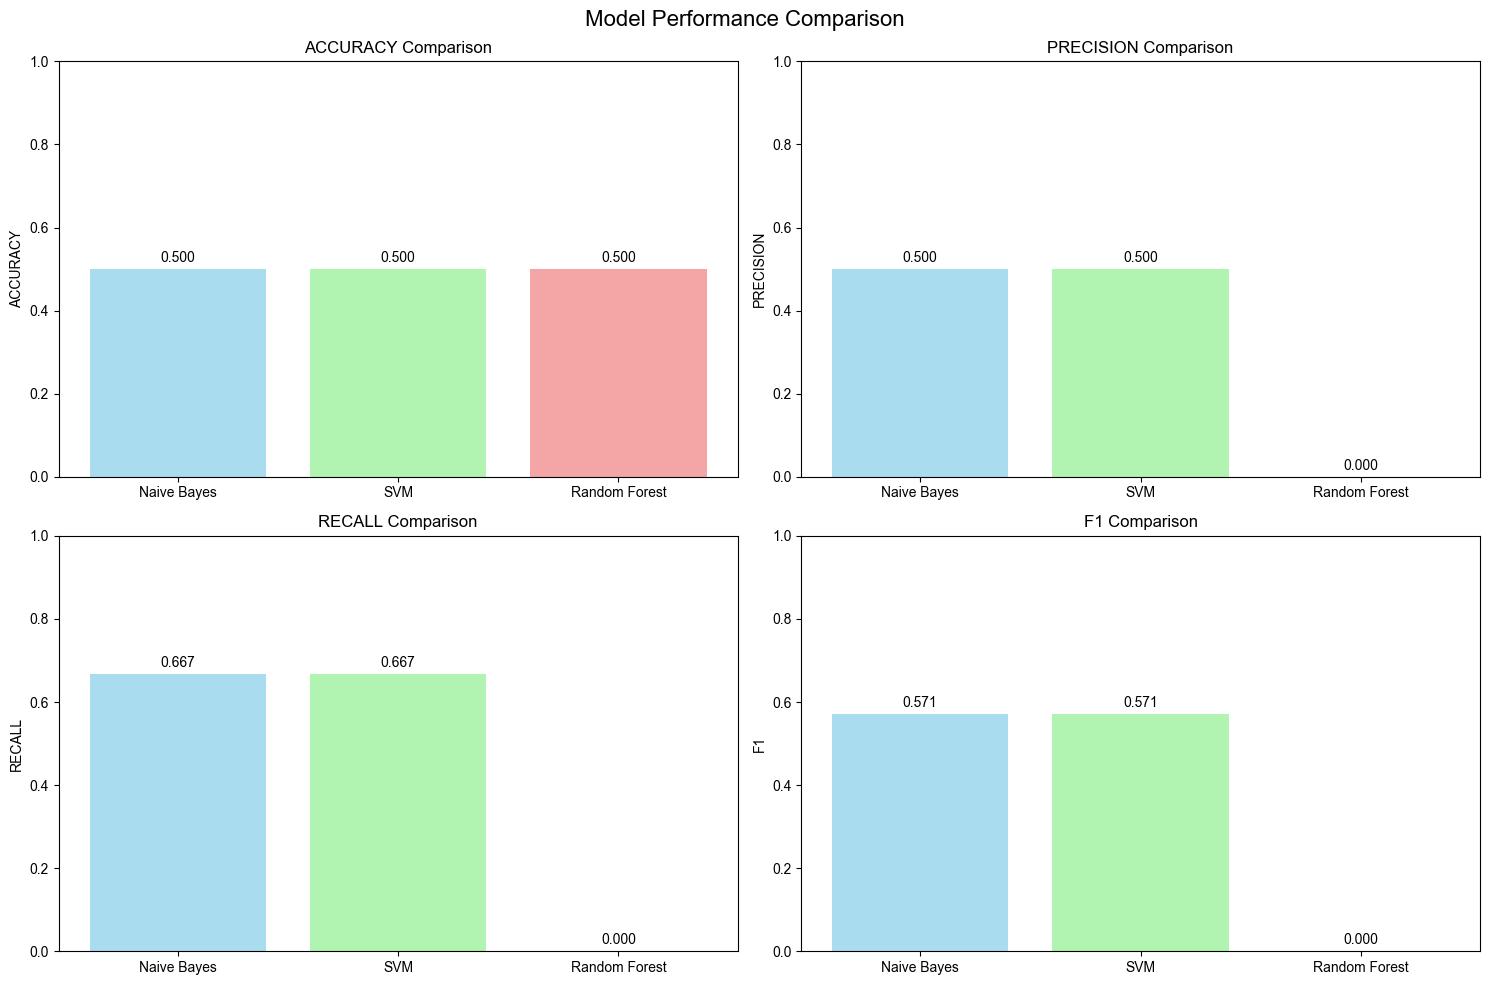

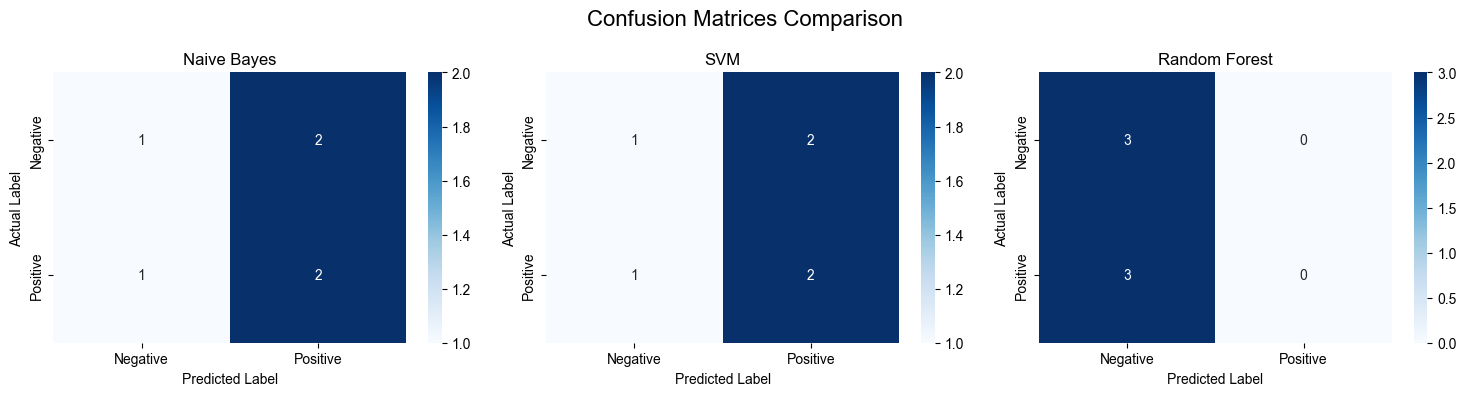


8. 预测新文本...
文本: 这部电影真的很棒，演员演技出色，剧情精彩
预测: 正面
置信度: 0.590

文本: 太无聊了，完全不推荐，浪费时间
预测: 负面
置信度: 0.567

文本: 一般般，有些地方不错，有些地方很差
预测: 负面
置信度: 0.500



In [ ]:
import pandas as pd
import numpy as np
import jieba
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')


# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

class ChineseTextClassifier:
    """中文文本分类器"""

    def __init__(self):
        """初始化分类器"""
        self.vectorizer = None
        self.models = {}
        self.stop_words = self._load_stop_words()
        self.is_fitted = False

    def _load_stop_words(self):
        """加载中文停用词"""
        stop_words = {
            '的', '了', '在', '是', '我', '有', '和', '就',
            '不', '人', '都', '一', '一个', '上', '也', '很',
            '到', '说', '要', '去', '你', '会', '着', '没有',
            '看', '好', '自己', '这样', '那么', '能', '下',
            '可以', '还', '比', '而', '来', '用', '从', '把',
            '被', '跟', '与', '对', '为', '以', '所', '当',
            '如果', '虽然', '但是', '然后', '因为', '所以'
        }
        return stop_words

    def preprocess_text(self, text):
        """文本预处理"""
        if not isinstance(text, str):
            return ""

        # 清理文本
        text = re.sub(r'[^\u4e00-\u9fff\w\s]', '', text)  # 保留中文和字母数字
        text = re.sub(r'\s+', ' ', text)  # 多个空格合并为一个
        text = text.strip()

        # 分词
        words = jieba.cut(text)

        # 过滤停用词和短词
        filtered_words = [
            word for word in words
            if word not in self.stop_words
            and len(word.strip()) > 1
            and not word.isdigit()
        ]

        return ' '.join(filtered_words)

    def create_sample_data(self):
        """创建示例数据集"""
        positive_reviews = [
            "这部电影太精彩了，剧情跌宕起伏，演员表演出色",
            "非常好看的电影，推荐大家观看，五星好评",
            "导演拍得很用心，每个细节都很棒，值得收藏",
            "演员演技在线，剧情引人入胜，是今年最佳电影",
            "画面精美，音乐动听，整体制作水准很高",
            "故事情节丰富，人物刻画深刻，观影体验极佳",
            "这是一部经典之作，值得反复观看和思考",
            "电影节奏把握得当，悬念设置巧妙，非常吸引人",
            "特效制作精良，视觉效果震撼，技术水平一流",
            "主题深刻，发人深省，是一部有内涵的好电影"
        ]

        negative_reviews = [
            "这部电影实在太无聊了，浪费时间和金钱",
            "剧情拖沓，节奏缓慢，看得让人昏昏欲睡",
            "演员表演生硬，台词尴尬，毫无代入感",
            "特效粗糙，制作粗制滥造，完全不值票价",
            "故事情节老套，毫无新意，预测性太强",
            "导演水平有限，整部电影缺乏亮点和深度",
            "音效刺耳，画面模糊，技术问题太多",
            "人物塑造失败，逻辑混乱，前后矛盾",
            "过度商业化，缺乏艺术性，纯粹圈钱之作",
            "结局草率，前面铺垫完全白费，严重失望"
        ]

        # 创建数据框
        data = []
        for review in positive_reviews:
            data.append({'review': review, 'sentiment': 1, 'label': '正面'})
        for review in negative_reviews:
            data.append({'review': review, 'sentiment': 0, 'label': '负面'})

        df = pd.DataFrame(data)
        return df

    def train_models(self, X_train, y_train):
        """训练多个分类模型"""
        models = {
            'Naive Bayes': MultinomialNB(alpha=1.0),
            'SVM': SVC(kernel='linear', C=1.0, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
        }

        print("开始训练模型...")
        for name, model in models.items():
            print(f"训练 {name}...")
            model.fit(X_train, y_train)
            self.models[name] = model

        self.is_fitted = True
        print("所有模型训练完成！")

    def evaluate_models(self, X_test, y_test):
        """评估所有模型性能"""
        results = {}

        for name, model in self.models.items():
            y_pred = model.predict(X_test)

            results[name] = {
                'accuracy': accuracy_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred),
                'recall': recall_score(y_test, y_pred),
                'f1': f1_score(y_test, y_pred),
                'predictions': y_pred
            }

        return results

    def plot_evaluation_results(self, results):
        """Visualize evaluation results"""
        metrics = ['accuracy', 'precision', 'recall', 'f1']
        models = list(results.keys())

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

        for i, metric in enumerate(metrics):
            ax = axes[i//2, i%2]
            values = [results[model][metric] for model in models]

            bars = ax.bar(models, values, alpha=0.7,
                        color=['skyblue', 'lightgreen', 'lightcoral'])
            ax.set_title(f'{metric.upper()} Comparison', fontsize=12)
            ax.set_ylabel(metric.upper())
            ax.set_ylim(0, 1)

            # Add value labels
            for bar, value in zip(bars, values):
                ax.text(bar.get_x() + bar.get_width()/2, value + 0.01,
                      f'{value:.3f}', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()


    def plot_confusion_matrices(self, results, y_test):
        """Plot confusion matrices"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle('Confusion Matrices Comparison', fontsize=16, fontweight='bold')

        for i, (name, result) in enumerate(results.items()):
            cm = confusion_matrix(y_test, result['predictions'])

            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['Negative', 'Positive'],
                        yticklabels=['Negative', 'Positive'],
                        ax=axes[i])
            axes[i].set_title(f'{name}')
            axes[i].set_xlabel('Predicted Label')
            axes[i].set_ylabel('Actual Label')

        plt.tight_layout()
        plt.show()

    def predict_sentiment(self, texts, model_name='Naive Bayes'):
        """预测文本情感"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练，请先调用fit方法")

        if isinstance(texts, str):
            texts = [texts]

        # 预处理文本
        processed_texts = [self.preprocess_text(text) for text in texts]

        # 特征提取
        X = self.vectorizer.transform(processed_texts)

        # 预测
        model = self.models[model_name]
        predictions = model.predict(X)
        probabilities = model.predict_proba(X) if hasattr(model, 'predict_proba') else None

        results = []
        for i, text in enumerate(texts):
            result = {
                'text': text,
                'prediction': '正面' if predictions[i] == 1 else '负面',
                'confidence': probabilities[i].max() if probabilities is not None else None
            }
            results.append(result)

        return results

# 演示完整的训练和评估流程
def demonstrate_sentiment_analysis():
    """演示情感分析系统"""
    print("=" * 60)
    print("中文电影评论情感分析系统演示")
    print("=" * 60)

    # 1. 创建分类器实例
    classifier = ChineseTextClassifier()

    # 2. 创建示例数据
    print("\n1. 创建示例数据集...")
    df = classifier.create_sample_data()
    print(f"数据集大小: {len(df)} 条评论")
    print("\n数据样例:")
    print(df.head())

    # 3. 数据预处理
    print("\n2. 数据预处理...")
    df['processed_review'] = df['review'].apply(classifier.preprocess_text)
    print("\n预处理前后对比:")
    for i in range(2):
        print(f"原文: {df.iloc[i]['review']}")
        print(f"处理后: {df.iloc[i]['processed_review']}")
        print()

    # 4. 特征提取
    print("3. 特征提取...")
    vectorizer = TfidfVectorizer(
        max_features=1000,
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.9
    )

    X = vectorizer.fit_transform(df['processed_review'])
    y = df['sentiment']
    classifier.vectorizer = vectorizer

    print(f"特征矩阵形状: {X.shape}")
    print(f"特征名称示例: {vectorizer.get_feature_names_out()[:10]}")

    # 5. 数据划分
    print("\n4. 数据划分...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    print(f"训练集大小: {X_train.shape[0]}")
    print(f"测试集大小: {X_test.shape[0]}")

    # 6. 模型训练
    print("\n5. 模型训练...")
    classifier.train_models(X_train, y_train)

    # 7. 模型评估
    print("\n6. 模型评估...")
    results = classifier.evaluate_models(X_test, y_test)

    # 打印详细结果
    for name, metrics in results.items():
        print(f"\n{name} 性能:")
        print(f"  准确率: {metrics['accuracy']:.3f}")
        print(f"  精确率: {metrics['precision']:.3f}")
        print(f"  召回率: {metrics['recall']:.3f}")
        print(f"  F1分数: {metrics['f1']:.3f}")

    # 8. 可视化结果
    print("\n7. 可视化结果...")
    classifier.plot_evaluation_results(results)
    classifier.plot_confusion_matrices(results, y_test)

    # 9. 预测新文本
    print("\n8. 预测新文本...")
    test_texts = [
        "这部电影真的很棒，演员演技出色，剧情精彩",
        "太无聊了，完全不推荐，浪费时间",
        "一般般，有些地方不错，有些地方很差"
    ]

    for text in test_texts:
        predictions = classifier.predict_sentiment(text)
        for pred in predictions:
            print(f"文本: {pred['text']}")
            print(f"预测: {pred['prediction']}")
            if pred['confidence']:
                print(f"置信度: {pred['confidence']:.3f}")
            print()

if __name__ == "__main__":
    demonstrate_sentiment_analysis()

In [ ]:
class ModelComparison:
    """模型对比工具"""

    def __init__(self):
        self.models = {
            'Multinomial NB': MultinomialNB(),
            'Gaussian NB': GaussianNB(),
            'Linear SVM': SVC(kernel='linear', probability=True),
            'RBF SVM': SVC(kernel='rbf', probability=True),
            'Random Forest': RandomForestClassifier(n_estimators=100),
            'Logistic Regression': LogisticRegression(max_iter=1000),
            'Gradient Boosting': GradientBoostingClassifier()
        }
        self.results = {}

    def cross_validate_models(self, X, y, cv=5):
        """交叉验证评估模型"""
        from sklearn.model_selection import cross_val_score
        from sklearn.preprocessing import StandardScaler

        # 标准化特征（对某些算法重要）
        if hasattr(X, 'toarray'):
            X_dense = X.toarray()
        else:
            X_dense = X

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_dense)

        for name, model in self.models.items():
            print(f"评估 {name}...")

            # 选择合适的数据格式
            if 'NB' in name and 'Multinomial' in name:
                X_model = X  # 多项式朴素贝叶斯使用原始稀疏矩阵
            elif 'NB' in name:
                X_model = X_scaled  # 高斯朴素贝叶斯使用标准化数据
            else:
                X_model = X_scaled

            # 交叉验证
            cv_scores = cross_val_score(model, X_model, y, cv=cv, scoring='f1')

            self.results[name] = {
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'cv_scores': cv_scores
            }

        return self.results

    def plot_model_comparison(self):
        """Visualize model comparison results"""
        models = list(self.results.keys())
        means = [self.results[model]['cv_mean'] for model in models]
        stds = [self.results[model]['cv_std'] for model in models]

        fig, ax = plt.subplots(figsize=(12, 6))

        # Create bar chart
        bars = ax.bar(models, means, yerr=stds, capsize=5,
                      alpha=0.7, color='skyblue')

        ax.set_title('Model Performance Comparison (5-Fold CV F1 Scores)', fontsize=14)
        ax.set_ylabel('F1 Score')
        ax.set_ylim(0, 1)

        # Rotate x-axis labels
        plt.xticks(rotation=45, ha='right')

        # Add value labels
        for bar, mean, std in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.01,
                    f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=10)

        plt.tight_layout()
        plt.show()

    def get_best_model(self):
        """获取最佳模型"""
        best_model = max(self.results.items(), key=lambda x: x[1]['cv_mean'])
        return best_model

完整的中文情感分析系统演示
扩展后数据集大小: 30 条评论

进行特征提取...

数据划分...

进行模型对比...
评估 Multinomial NB...
评估 Gaussian NB...
评估 Linear SVM...
评估 RBF SVM...
评估 Random Forest...
评估 Logistic Regression...
评估 Gradient Boosting...


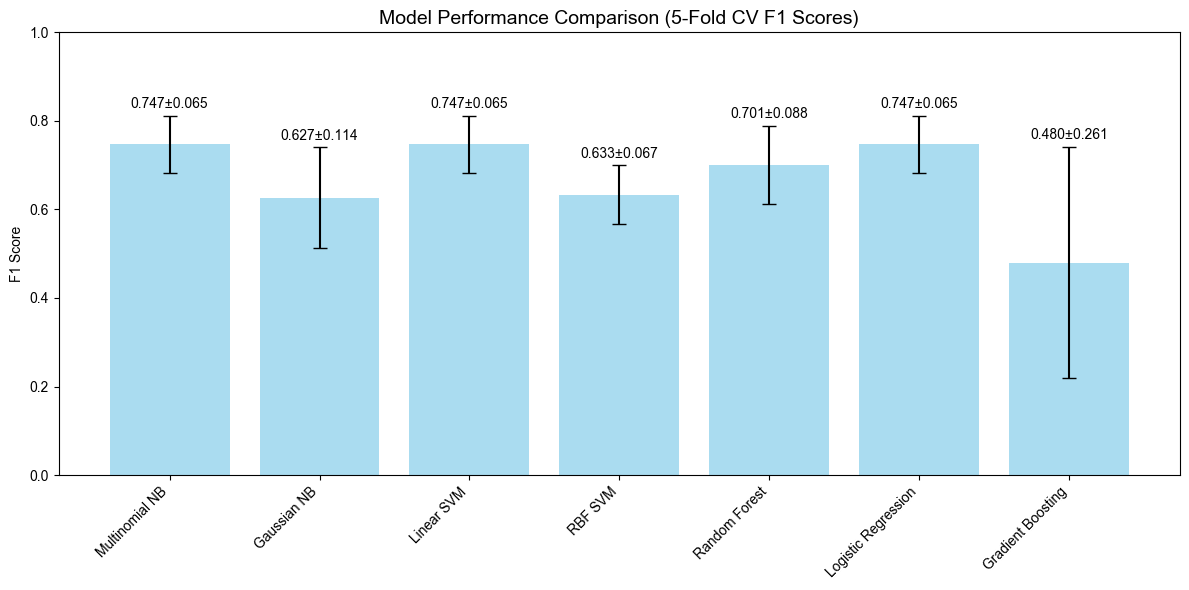


最佳模型: Linear SVM
平均F1分数: 0.747 ± 0.065


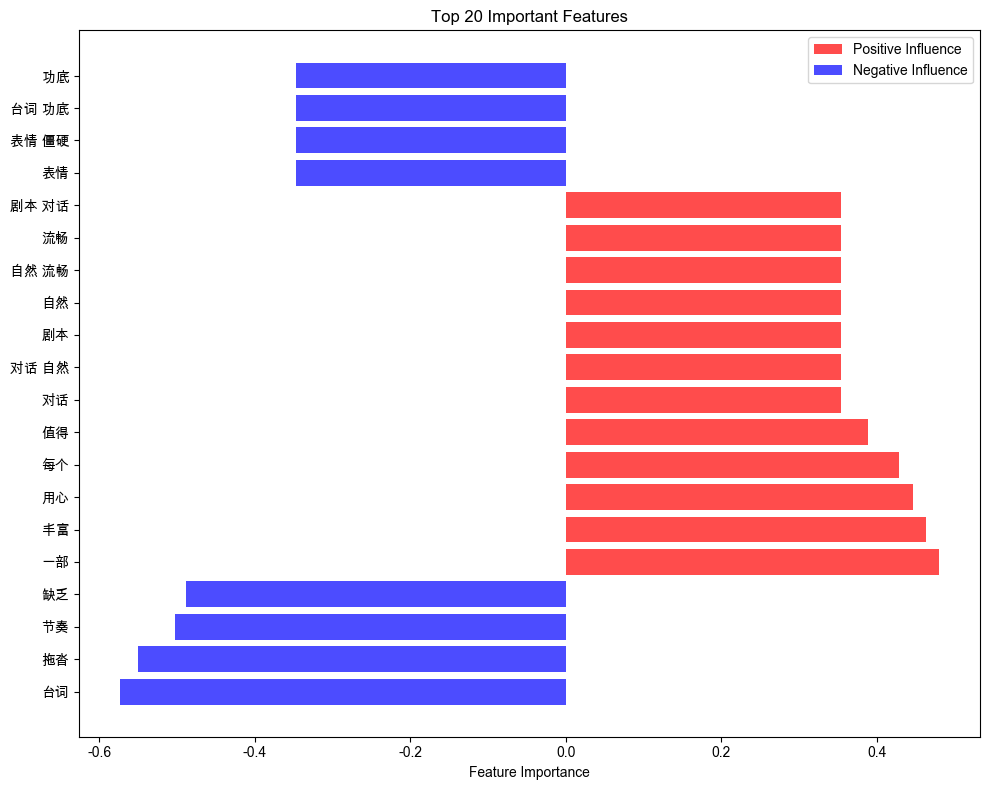


预测示例:

文本: 这部电影的视觉效果令人震撼，故事情节也很吸引人
预测: 正面
置信度: 0.768
激活特征: ['吸引(0.416)', '视觉效果(0.416)', '震撼(0.416)', '故事情节(0.371)', '这部(0.371)']

文本: 完全是在浪费时间，剧情无聊透顶
预测: 负面
置信度: 0.921
激活特征: ['无聊(0.556)', '浪费时间(0.556)', '完全(0.453)', '剧情(0.420)']

文本: 有些地方不错，但整体来说比较平庸
预测: 正面
置信度: 0.568
激活特征: ['整体(1.000)']


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
import numpy as np


class ModelInterpreter:
    """模型解释工具"""

    def __init__(self, model, vectorizer):
        self.model = model
        self.vectorizer = vectorizer
        self.feature_names = vectorizer.get_feature_names_out()

    def get_feature_importance(self, top_n=20):
        """获取特征重要性"""
        if hasattr(self.model, 'feature_log_prob_'):
            # 朴素贝叶斯
            feature_importance = np.exp(self.model.feature_log_prob_[1]) - np.exp(self.model.feature_log_prob_[0])
        elif hasattr(self.model, 'coef_'):
            # Linear models (like LinearSVC, LogisticRegression) have coef_
            feature_importance = self.model.coef_[0]
        elif hasattr(self.model, 'feature_importances_'):
            # Tree models (like RandomForest, GradientBoosting) have feature_importances_
            feature_importance = self.model.feature_importances_
        else:
            return None

        if feature_importance is not None:
            # Get important features
            indices = np.argsort(np.abs(feature_importance))[-top_n:]
            important_features = [(self.feature_names[i], feature_importance[i]) for i in indices]
            important_features.sort(key=lambda x: abs(x[1]), reverse=True)
        else:
            important_features = None


        return important_features


    def explain_prediction(self, text, preprocess_func=None):
        """解释单个预测"""
        if preprocess_func:
            processed_text = preprocess_func(text)
        else:
            processed_text = text

        # Get feature vector
        feature_vector = self.vectorizer.transform([processed_text])

        # Always convert to dense numpy array if the model is SVC
        if isinstance(self.model, SVC):
            feature_vector_for_prediction = feature_vector.toarray()
        else:
            feature_vector_for_prediction = feature_vector


        # Predict
        prediction = self.model.predict(feature_vector_for_prediction)[0]
        if hasattr(self.model, 'predict_proba'):
            probabilities = self.model.predict_proba(feature_vector_for_prediction)[0]
            prob = probabilities.max()
        else:
            prob = None

        # Find activated features (use the original sparse or converted dense based on model type)
        activated_features = []
        # Convert to dense for feature analysis if not already dense
        if hasattr(feature_vector, 'toarray'):
             feature_vector_flat = feature_vector.toarray().flatten()
        else:
             feature_vector_flat = feature_vector.flatten()


        for i, value in enumerate(feature_vector_flat):
            if value > 0:
                activated_features.append((self.feature_names[i], value))

        activated_features.sort(key=lambda x: x[1], reverse=True)

        return {
            'text': text,
            'prediction': prediction,
            'confidence': prob,
            'activated_features': activated_features[:10]
        }


    def plot_feature_importance(self, top_n=20):
        """Visualize feature importance"""
        important_features = self.get_feature_importance(top_n)

        if important_features is None:
            print("This model does not support feature importance analysis")
            return

        features, importances = zip(*important_features)

        fig, ax = plt.subplots(figsize=(10, 8))

        # Color coding: positive = red, negative = blue
        colors = ['red' if imp > 0 else 'blue' for imp in importances]

        bars = ax.barh(range(len(features)), importances, color=colors, alpha=0.7)
        ax.set_yticks(range(len(features)))
        ax.set_yticklabels(features)
        ax.set_xlabel('Feature Importance')
        ax.set_title(f'Top {top_n} Important Features')

        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='red', alpha=0.7, label='Positive Influence'),
            Patch(facecolor='blue', alpha=0.7, label='Negative Influence')
        ]
        ax.legend(handles=legend_elements)

        plt.tight_layout()
        plt.show()

# 完整演示代码
def complete_sentiment_analysis_demo():
    """完整的中文情感分析系统演示"""
    print("=" * 80)
    print("完整的中文情感分析系统演示")
    print("=" * 80)

    # 1. 创建并准备数据
    classifier = ChineseTextClassifier()
    df = classifier.create_sample_data()

    # 扩展数据集
    additional_positive = [
        "导演功力深厚，每个镜头都很有意义",
        "音乐配得恰到好处，增色不少",
        "这个演员的表演层次丰富，很有感染力",
        "剧本写得很好，对话自然流畅",
        "场景设计用心，服装道具都很精致"
    ]

    additional_negative = [
        "剪辑混乱，故事讲述不清楚",
        "演员台词功底差，表情僵硬",
        "特效五毛钱，完全没有说服力",
        "剧情逻辑漏洞百出，经不起推敲",
        "节奏拖沓，很多情节都是多余的"
    ]

    additional_data = []
    for review in additional_positive:
        additional_data.append({'review': review, 'sentiment': 1, 'label': '正面'})
    for review in additional_negative:
        additional_data.append({'review': review, 'sentiment': 0, 'label': '负面'})

    df_additional = pd.DataFrame(additional_data)
    df = pd.concat([df, df_additional], ignore_index=True)


    print(f"扩展后数据集大小: {len(df)} 条评论")

    # 2. 高级特征提取
    # Assuming AdvancedFeatureExtractor is defined elsewhere or needs to be defined
    # For now, I'll use the TfidfVectorizer from the ChineseTextClassifier
    # If AdvancedFeatureExtractor is needed, please provide its code.
    print("\n进行特征提取...")
    processed_texts = [classifier.preprocess_text(text) for text in df['review']]
    vectorizer = TfidfVectorizer(
        max_features=1000,
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.9
    )
    X = vectorizer.fit_transform(processed_texts)
    y = df['sentiment']

    # Assign the vectorizer to the classifier instance if needed later for prediction
    classifier.vectorizer = vectorizer

    # 3. 数据划分
    print("\n数据划分...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # 4. 模型对比
    print("\n进行模型对比...")
    comparison = ModelComparison()
    results = comparison.cross_validate_models(X_train, y_train)
    comparison.plot_model_comparison()

    best_model_name, best_result = comparison.get_best_model()
    print(f"\n最佳模型: {best_model_name}")
    print(f"平均F1分数: {best_result['cv_mean']:.3f} ± {best_result['cv_std']:.3f}")

    # 5. 训练最佳模型
    best_model = comparison.models[best_model_name]
    # Check if X_train is sparse and convert to dense if the model doesn't support sparse input
    if hasattr(X_train, 'toarray') and not hasattr(best_model, 'sparse_output_'):
        X_train_for_best_model = X_train.toarray()
    else:
        X_train_for_best_model = X_train

    best_model.fit(X_train_for_best_model, y_train)


    # 6. 模型解释
    interpreter = ModelInterpreter(best_model, vectorizer)
    interpreter.plot_feature_importance()

    # 7. 预测示例
    test_examples = [
        "这部电影的视觉效果令人震撼，故事情节也很吸引人",
        "完全是在浪费时间，剧情无聊透顶",
        "有些地方不错，但整体来说比较平庸"
    ]

    print("\n预测示例:")
    for text in test_examples:
        explanation = interpreter.explain_prediction(text, classifier.preprocess_text)
        print(f"\n文本: {explanation['text']}")
        print(f"预测: {'正面' if explanation['prediction'] == 1 else '负面'}")
        if explanation['confidence'] is not None:
            print(f"置信度: {explanation['confidence']:.3f}")
        print("激活特征:", [f"{feat}({val:.3f})" for feat, val in explanation['activated_features'][:5]])

if __name__ == "__main__":
    complete_sentiment_analysis_demo()